In [2]:
import pandas as pd
from scipy import stats
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [13]:
df = pd.read_csv(r'..\data\5_task_1.csv')

In [ ]:
# Проверил гомогенность дисперсий с помощью теста Левена (p > 0.05). Все хорошо. Поэтому использую классическую ANOVA.

In [ ]:
stat, p = stats.levene(df['events'].loc[df['group']== 'A'], df['events'].loc[df['group']== 'B'], df['events'].loc[df['group']== 'C'])
print("stat =", stat)
print("p =", p)

stat = 2.2622596339318033
p = 0.10413271994973812


<Axes: xlabel='events', ylabel='Count'>

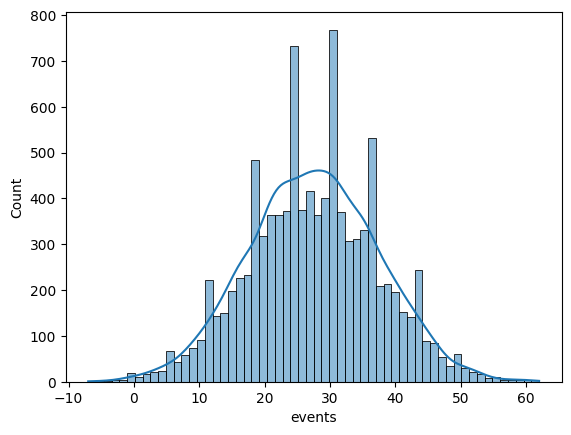

In [ ]:
sns.histplot(data=df['events'].loc[df['group']== 'C'], kde=True)

In [ ]:
df.groupby('group',as_index=False).mean()

,group,id,events
0,A,14984.7227,29.5796
1,B,15009.0425,37.6136
2,C,15004.7348,27.4703


In [ ]:
f_stat, p_value = stats.f_oneway(df['events'].loc[df['group']== 'A'], df['events'].loc[df['group']== 'B'], df['events'].loc[df['group']== 'C'])
print("f_stat =", f_stat)
print("p_value =", p_value)

f_stat = 2886.16665743896
p_value = 0.0


In [ ]:
tukey = pairwise_tukeyhsd(endog=df['events'], groups=df['group'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper  reject
----------------------------------------------------
     A      B    8.034   0.0   7.7038  8.3642   True
     A      C  -2.1093   0.0  -2.4395 -1.7791   True
     B      C -10.1433   0.0 -10.4735 -9.8131   True
----------------------------------------------------


In [ ]:
# внедряемые группу B, тоесть картинку с квадратным разрешением

In [14]:
df_2 = pd.read_csv(r'..\data\5_task_2.csv')

In [ ]:
df_2.groupby(['segment', 'group'], as_index=False).mean()

,segment,group,id,events
0,high,control,50473.9782,59.970800
1,high,test,50126.6206,69.938500
2,low,control,49935.2567,20.031575
3,low,test,49913.3436,33.025925


In [ ]:
stat, p_value = stats.levene(df_2['events'].loc[(df_2['group'] == 'test')], df_2['events'].loc[(df_2['group'] == 'control')])
print("stat =", stat)
print("p =", p_value)

stat = 2.5440050816535327
p = 0.11071679230511801


In [ ]:
two_way = ols('events ~ C(group) * C(segment)', data=df_2).fit()

anova_table_two = sm.stats.anova_lm(two_way, typ = 2)
print(anova_table_two)

                           sum_sq       df              F         PR(>F)
C(group)             3.837195e+06      1.0  112031.864119   0.000000e+00
C(segment)           2.362480e+07      1.0  689756.377484   0.000000e+00
C(group):C(segment)  3.664244e+04      1.0    1069.823273  2.060261e-233
Residual             3.424956e+06  99996.0            NaN            NaN


In [ ]:
# эффект теста зависит от сегмента, в low сегменте эффект сильнее (разница между control и test в low сегменте - 13%, а в high - 10%)
# новая версия кнопки увеличивает метрику в обоих сегментах пользователей. Эффект положительный во всех группах, поэтому рекомендую внедрить новую кнопку для всех пользователей.